In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/india_agriculture_seed_sales_data.csv')


In [2]:
# Portfolio Status 
veg_margin = df.groupby('Vegetable_Type').agg(
    Avg_Profit_Margin=('Profit_Margin_%', 'mean'),
    Total_Revenue_M=('Total_Revenue', lambda x: x.sum() / 1e6),
    Total_Units_Sold=('Actual_Units_Sold', 'sum'),
    Avg_Cost=('Total_Cost', 'mean'),
    Avg_Seed_Price=('Seed_Price_Per_Unit', 'mean'),
    Avg_Competitor_Share=('Competitor_Market_Share_%', 'mean')
).reset_index()
veg_margin['Status'] = veg_margin['Avg_Profit_Margin'].apply(
    lambda x: '🔴 PHASE OUT' if x < 1.5 else '🟡 MONITOR' if x < 5 else '🟢 HEALTHY')

print('=' * 65)
print('PORTFOLIO PROFITABILITY STATUS')
print('=' * 65)
print(veg_margin[['Vegetable_Type', 'Avg_Profit_Margin', 'Total_Revenue_M', 'Status']]
      .sort_values('Avg_Profit_Margin').to_string(index=False))

phase_out = veg_margin[veg_margin['Avg_Profit_Margin'] < 1.5]
healthy   = veg_margin[veg_margin['Avg_Profit_Margin'] >= 5]
print(f'\n📛 Phase-out candidates ({len(phase_out)} products):',
      list(phase_out['Vegetable_Type']))
print(f'✅ Healthy portfolio ({len(healthy)} products):',
      list(healthy['Vegetable_Type']))


PORTFOLIO PROFITABILITY STATUS
Vegetable_Type  Avg_Profit_Margin  Total_Revenue_M    Status
         Onion           6.123302       624.009737 🟢 HEALTHY
        Tomato           6.131164       583.412786 🟢 HEALTHY
          Okra           6.133411       582.617594 🟢 HEALTHY
        Carrot           6.151602       579.048676 🟢 HEALTHY
         Chili           6.160407       578.856977 🟢 HEALTHY
   Cauliflower           6.181899       607.075630 🟢 HEALTHY

📛 Phase-out candidates (0 products): []
✅ Healthy portfolio (6 products): ['Carrot', 'Cauliflower', 'Chili', 'Okra', 'Onion', 'Tomato']



Year-over-Year Profit Margin by Vegetable:
Year            2021  2022  2023  2024  2025  2026
Vegetable_Type                                    
Carrot          11.4   9.0   7.0   4.4   3.0   2.0
Cauliflower     11.5   8.9   6.8   4.5   3.0   2.0
Chili           11.4   8.9   7.0   4.6   3.1   2.0
Okra            11.6   9.0   7.0   4.4   3.0   2.0
Onion           11.6   9.0   6.9   4.5   3.0   2.0
Tomato          11.4   9.0   7.0   4.5   3.0   2.0


e:\Portfolio Project\GREEN HARVEST SEEDS INDIA PVT. LTD\Project\venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
e:\Portfolio Project\GREEN HARVEST SEEDS INDIA PVT. LTD\Project\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


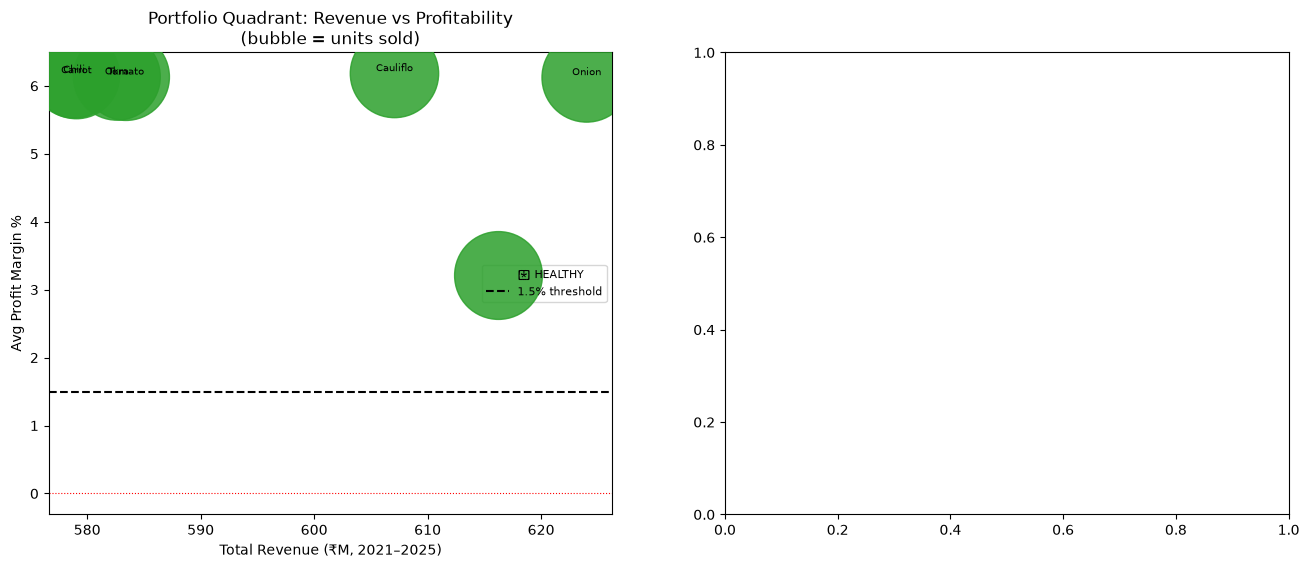

In [3]:
# Year-over-Year Margin Compression
yr_veg = df.pivot_table(values='Profit_Margin_%', index='Vegetable_Type',
                         columns='Year', aggfunc='mean')
print('\nYear-over-Year Profit Margin by Vegetable:')
print(yr_veg.round(1).to_string())

# ── Fig 1 Portfolio Quadrant 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_map = {'🔴 PHASE OUT': '#d62728', '🟡 MONITOR': '#ff7f0e', '🟢 HEALTHY': '#2ca02c'}
for status, grp in veg_margin.groupby('Status'):
    axes[0].scatter(grp['Total_Revenue_M'], grp['Avg_Profit_Margin'],
                    s=grp['Total_Units_Sold'] / 800,
                    c=colors_map[status], label=status, alpha=0.85, zorder=3)
    for _, row in grp.iterrows():
        axes[0].annotate(row['Vegetable_Type'][:8],
                         (row['Total_Revenue_M'], row['Avg_Profit_Margin']),
                         fontsize=7, ha='center', va='bottom')

axes[0].axhline(1.5, color='black', lw=1.5, linestyle='--', label='1.5% threshold')
axes[0].axhline(0, color='red', lw=0.8, linestyle=':')
axes[0].set_xlabel('Total Revenue (₹M, 2021–2025)')
axes[0].set_ylabel('Avg Profit Margin %')
axes[0].set_title('Portfolio Quadrant: Revenue vs Profitability\n(bubble = units sold)')
axes[0].legend(fontsize=8)



Saved: profitability_analysis.png


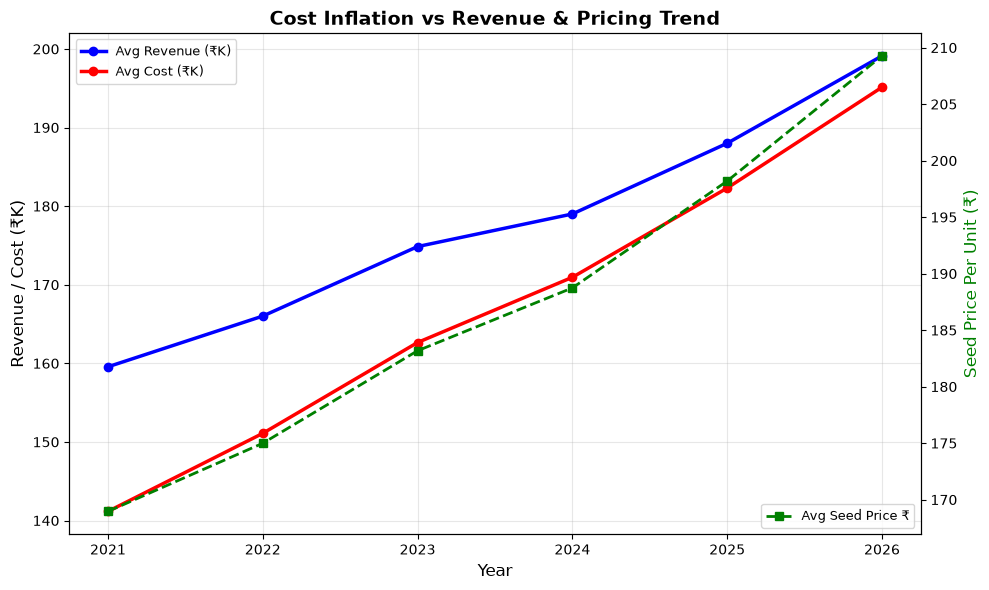

In [ ]:
# Create figure and axes properly
fig, ax = plt.subplots(figsize=(10, 6))

# Cost vs Price trend by year
yr_data = df.groupby('Year').agg(
    Avg_Cost_K=('Total_Cost', lambda x: x.mean() / 1000),
    Avg_Rev_K=('Total_Revenue', lambda x: x.mean() / 1000),
    Avg_Price=('Seed_Price_Per_Unit', 'mean')
).reset_index()

# Create twin axis for seed price
ax_twin = ax.twinx()

# Plot revenue and cost on primary axis
ax.plot(yr_data['Year'], yr_data['Avg_Rev_K'], 'b-o', lw=2.5, label='Avg Revenue (₹K)')
ax.plot(yr_data['Year'], yr_data['Avg_Cost_K'], 'r-o', lw=2.5, label='Avg Cost (₹K)')

# Plot seed price on secondary axis
ax_twin.plot(yr_data['Year'], yr_data['Avg_Price'], 'g--s', lw=2, label='Avg Seed Price ₹')

# Labels and titles
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Revenue / Cost (₹K)', fontsize=12)
ax_twin.set_ylabel('Seed Price Per Unit (₹)', color='green', fontsize=12)
ax.set_title('Cost Inflation vs Revenue & Pricing Trend', fontweight='bold', fontsize=14)

# Legends
ax.legend(loc='upper left', fontsize=9)
ax_twin.legend(loc='lower right', fontsize=9)

# Grid for better readability
ax.grid(True, alpha=0.3)

# Tight layout
plt.tight_layout()

plt.savefig('../outputs/figures/profitability_analysis.png', bbox_inches='tight', dpi=300)
print('\nSaved: profitability_analysis.png')


plt.show()

Saved: margin_compression_heatmap.png


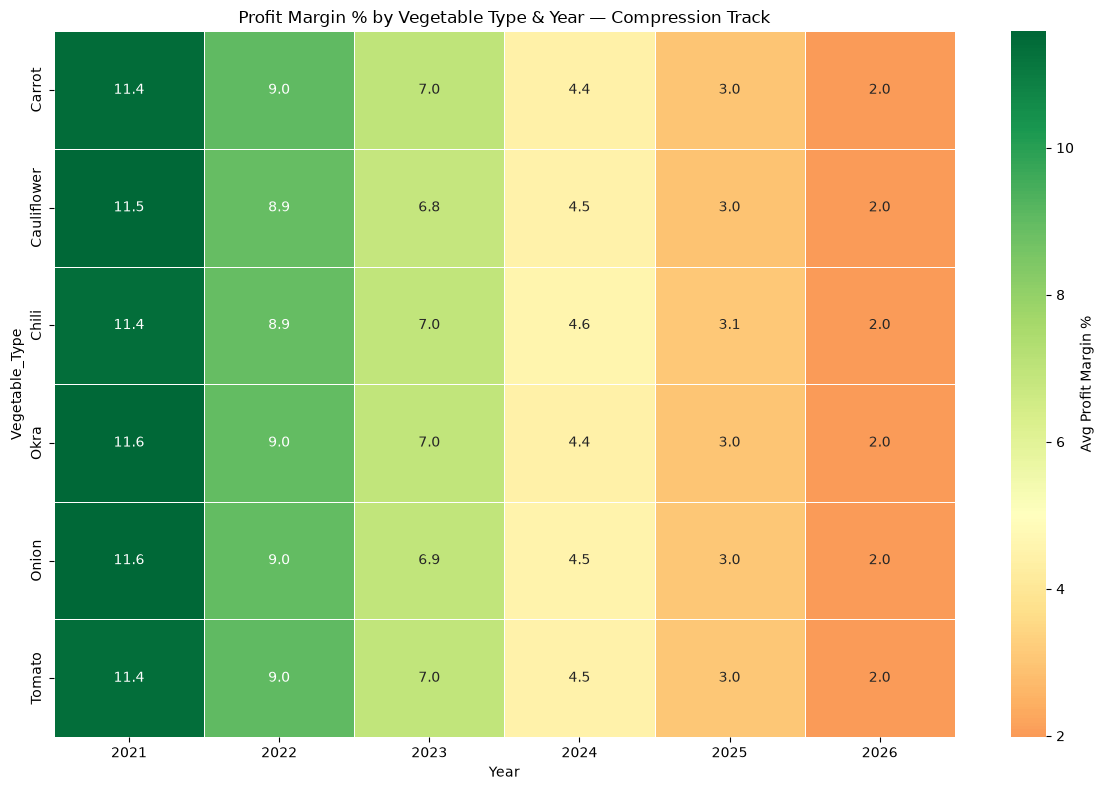

In [7]:
 # Margin Compression Heatmap 
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(yr_veg, annot=True, fmt='.1f', cmap='RdYlGn', center=5,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Avg Profit Margin %'})
ax.set_title('Profit Margin % by Vegetable Type & Year — Compression Track')
plt.tight_layout()
plt.savefig('../outputs/figures/margin_compression_heatmap.png', bbox_inches='tight')
print('Saved: margin_compression_heatmap.png')

plt.show()


Region × Crop Profitability Matrix

In [9]:
pivot = df.pivot_table(
    values='Profit_Margin_%',
    index='Region',
    columns='Vegetable_Type',
    aggfunc='mean'
).round(1)
print(pivot)

Vegetable_Type  Carrot  Cauliflower  Chili  Okra  Onion  Tomato
Region                                                         
Central            6.2          6.4    6.2   6.0    6.0     6.2
East               6.0          6.2    6.3   6.3    6.1     6.2
North              6.2          6.0    6.2   6.0    6.3     6.0
South              6.2          6.1    6.0   6.1    6.0     6.1
West               6.2          6.2    6.2   6.2    6.2     6.2


Loss-Making Segments

In [10]:
loss = df[df['Profit_Margin_%'] < 0].groupby(
    ['Region','Vegetable_Type']
)['Profit_Margin_%'].mean().round(2).sort_values().head(10)
print("Top 10 Loss-Making Segments(region + Vagetable):")
print(loss)

Top 10 Loss-Making Segments(region + Vagetable):
Series([], Name: Profit_Margin_%, dtype: float64)


So no segment is in loss.